# Question 01

In [ ]:
import cv2 as cv
import numpy as np

image_1b = cv.imread('a1images/emma.jpg')

c = np.array([(50,100),(150,255)])

transform = np.arange(256,dtype='uint8')

transform[c[0,0]:c[0,1]+1] = np.linspace(c[1,0],c[1,1],c[0,1]-c[0,0]+1).astype('uint8')

image_1b_out = cv.LUT(image_1b,transform)

cv.imshow('image_1b_out', image_1b_out)
cv.waitKey(0)
cv.destroyAllWindows()

# Question 02

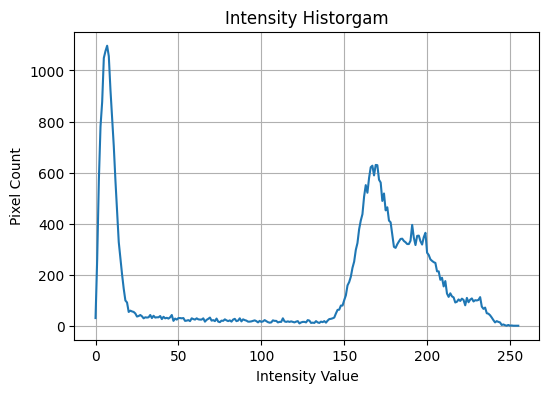

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image_2 = cv.imread('a1images/brain_proton_density_slice.png',cv.IMREAD_GRAYSCALE)

histogram = cv.calcHist([image_2], [0], None, [256], [0, 256])

plt.figure(figsize=(6, 4))
plt.plot(histogram)
plt.title('Intensity Historgam')
plt.xlabel('Intensity Value')
plt.ylabel('Pixel Count')
plt.grid(True)
plt.show()

In [37]:
#Grey Matter --> 150-190
import cv2 as cv
import numpy as np

image_2 = cv.imread('a1images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)

c = np.array([(150,190),(200,255)])
ri = 30 # reduced intensity

transform = np.arange(256, dtype='uint8')

transform[0:c[0,0]+1] = np.linspace(0, c[0,0]-ri, c[0,0]+1).astype('uint8')
transform[c[0,0]:c[0,1]+1] = np.linspace(c[1,0], c[1,1], c[0,1]-c[0,0]+1).astype('uint8') # Grey Matter boosted
transform[c[0,1]+1:256] = np.linspace(c[1,1]-ri, 255, 256-(c[0,1]+1)).astype('uint8')

image_2_out_1 = cv.LUT(image_2, transform)

cv.imshow('image_2_out_1', image_2_out_1)
cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
#White Matter --> 190 -255

import cv2 as cv
import numpy as np

image_2 = cv.imread('a1images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)

c = np.array([(190,255),(245,255)])
ri = 30 # reduced intensity

transform = np.arange(256, dtype='uint8')

transform[0:c[0,0]+1] = np.linspace(0, c[0,0]-ri, c[0,0]+1).astype('uint8')
transform[c[0,0]:c[0,1]+1] = np.linspace(c[1,0], c[1,1], c[0,1]-c[0,0]+1).astype('uint8') # Grey Matter boosted
transform[c[0,1]+1:256] = np.linspace(c[1,1]-ri, 255, 256-(c[0,1]+1)).astype('uint8')

image_2_out_1 = cv.LUT(image_2, transform)

cv.imshow('image_2_out_1', image_2_out_1)
cv.waitKey(0)
cv.destroyAllWindows()

# Question 03

In [43]:
import cv2 as cv
import numpy as np

gamma = 2.2

image_3 = cv.imread('a1images/highlights_and_shadows.jpg')
lab = cv.cvtColor(image_3, cv.COLOR_BGR2Lab)
L, a, b = cv.split(lab)

gamma_LUT = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(256)]).astype("uint8")

L_gamma = cv.LUT(L, gamma_LUT)
lab_gamma = cv.merge([L_gamma, a, b])

image_3_out = cv.cvtColor(lab_gamma, cv.COLOR_Lab2BGR)

cv.imshow("Original", image_3)
cv.imshow("Gamma Corrected", image_3_out)
cv.waitKey(0)
cv.destroyAllWindows()

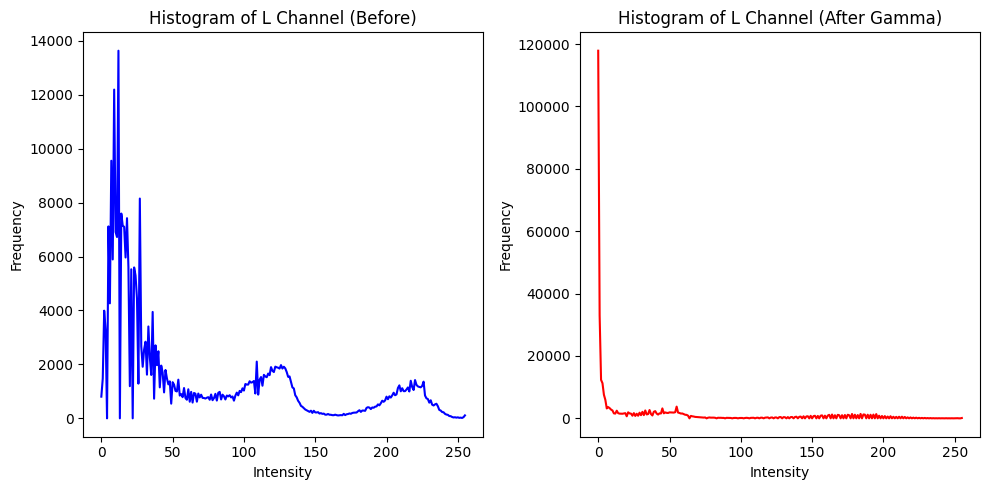

In [44]:
hist_before = cv.calcHist([L], [0], None, [256], [0,256])

hist_after = cv.calcHist([L_gamma], [0], None, [256], [0,256])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hist_before, color='blue')
plt.title("Histogram of L Channel (Before)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.plot(hist_after, color='red')
plt.title("Histogram of L Channel (After Gamma)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Question 04

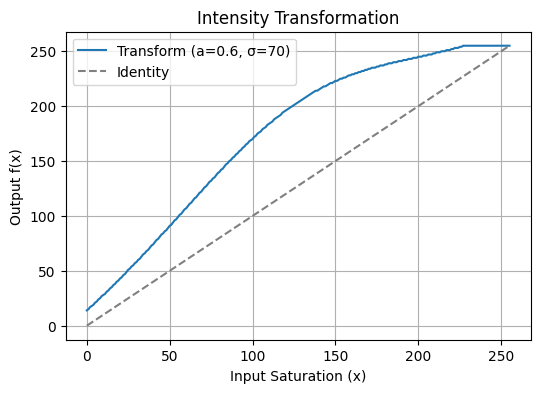

In [4]:
import cv2 as cv
import numpy as np

image_4 = cv.imread('a1images/spider.png')

hsv = cv.cvtColor(image_4, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

sigma = 70
a = 0.6

x = np.arange(256)
transform = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
transform = np.clip(transform, 0, 255).astype(np.uint8)

S_new = cv.LUT(S, transform)

hsv_new = cv.merge([H, S_new, V])
image_vibrant = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)

cv.imshow("Original", image_4)
cv.imshow("Vibrance Enhanced", image_vibrant)

plt.figure(figsize=(6,4))
plt.plot(x, transform, label=f"Transform (a={a}, σ={sigma})")
plt.plot(x, x, '--', color='gray', label="Identity")
plt.xlabel("Input Saturation (x)")
plt.ylabel("Output f(x)")
plt.title("Intensity Transformation")
plt.legend()
plt.grid(True)
plt.show()

cv.waitKey(0)
cv.destroyAllWindows()


# Question 05

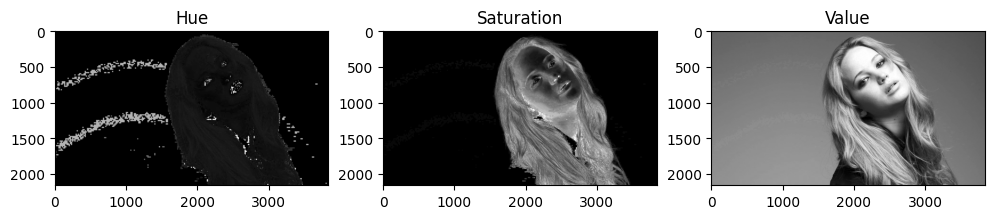

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("a1images/jeniffer.jpg")
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(h, cmap='gray'); plt.title("Hue")
plt.subplot(1, 3, 2); plt.imshow(s, cmap='gray'); plt.title("Saturation")
plt.subplot(1, 3, 3); plt.imshow(v, cmap='gray'); plt.title("Value")
plt.show()

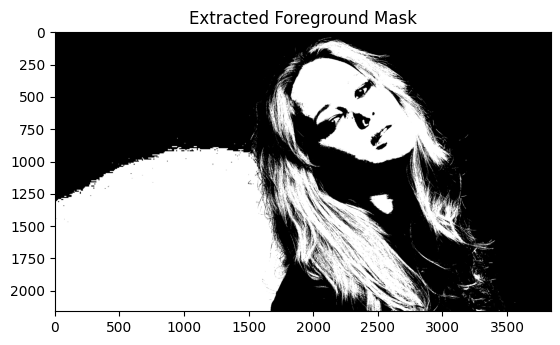

In [7]:
_, mask = cv.threshold(v, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

plt.imshow(mask, cmap='gray'); plt.title("Extracted Foreground Mask"); plt.show()

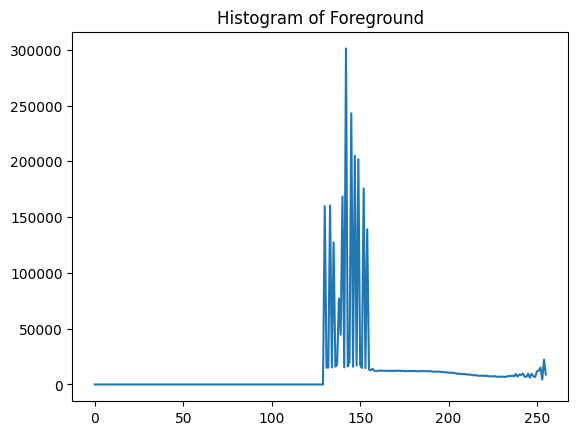

In [8]:
foreground = cv.bitwise_and(v, v, mask=mask)
hist = cv.calcHist([foreground], [0], mask, [256], [0,256])
plt.plot(hist); plt.title("Histogram of Foreground"); plt.show()

In [9]:
L = 256                     # Number of intensity levels
MN = np.sum(mask > 0)       # Total number of pixels in foreground

cdf = hist.cumsum()
cdf_normalized = cdf / MN   

t = np.array([(L - 1) * cdf_normalized[k] for k in range(L)], dtype=np.uint8)

equalized_foreground = t[foreground]

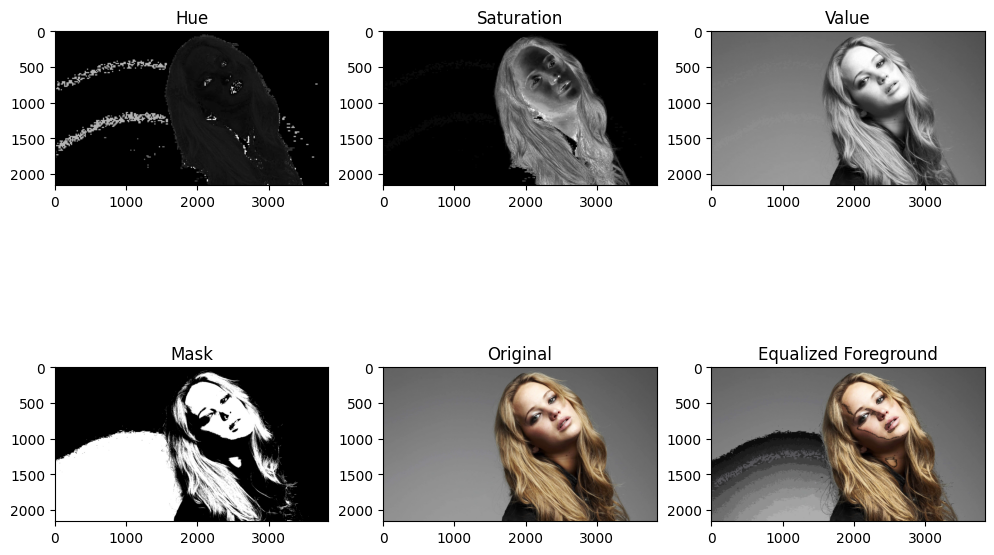

In [10]:
background = cv.bitwise_and(v, v, mask=cv.bitwise_not(mask))
result_v = cv.add(background, equalized_foreground)


result_hsv = cv.merge([h, s, result_v])
result_img = cv.cvtColor(result_hsv, cv.COLOR_HSV2BGR)


plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1); plt.imshow(h, cmap='gray'); plt.title("Hue")
plt.subplot(2, 3, 2); plt.imshow(s, cmap='gray'); plt.title("Saturation")
plt.subplot(2, 3, 3); plt.imshow(v, cmap='gray'); plt.title("Value")
plt.subplot(2, 3, 4); plt.imshow(mask, cmap='gray'); plt.title("Mask")
plt.subplot(2, 3, 5); plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(2, 3, 6); plt.imshow(cv.cvtColor(result_img, cv.COLOR_BGR2RGB)); plt.title("Equalized Foreground")
plt.show()

# Question 06

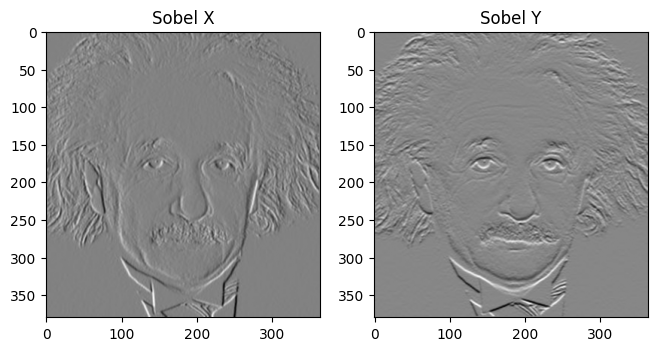

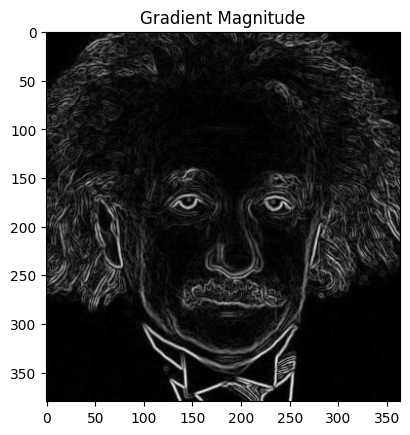

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


image_6 = cv.imread("a1images/einstein.png", cv.IMREAD_GRAYSCALE)

# Sobel kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

# Apply filter2D
grad_x = cv.filter2D(image_6, cv.CV_64F, sobel_x)
grad_y = cv.filter2D(image_6, cv.CV_64F, sobel_y)

# Compute gradient magnitude
grad_mag = np.sqrt(grad_x**2 + grad_y**2)
grad_mag = np.uint8(255 * grad_mag / np.max(grad_mag))


plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 2); plt.imshow(grad_x, cmap='gray'); plt.title("Sobel X")
plt.subplot(1, 3, 3); plt.imshow(grad_y, cmap='gray'); plt.title("Sobel Y")
plt.show()

plt.imshow(grad_mag, cmap='gray'); plt.title("Gradient Magnitude"); plt.show()


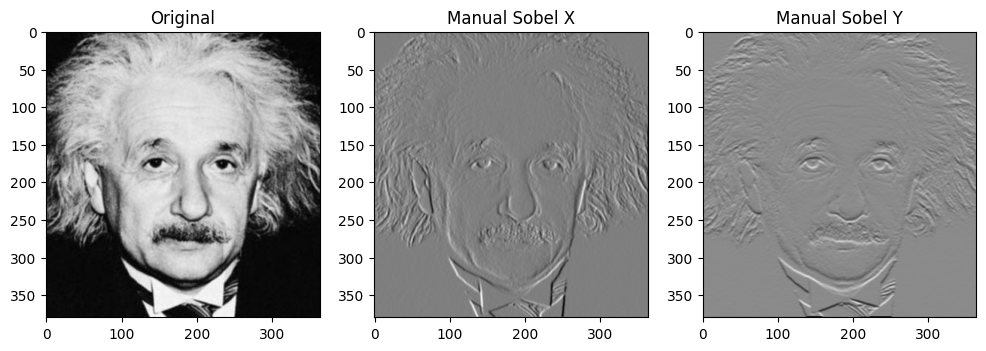

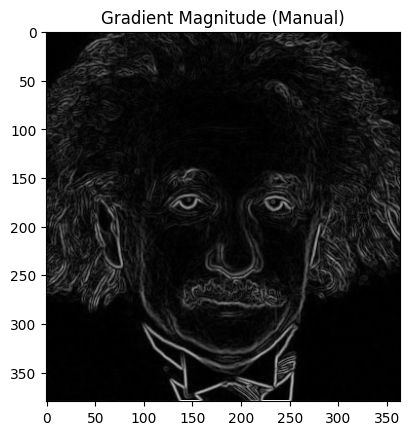

In [ ]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

def convolve(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2
    padded = np.pad(image, pad, mode='constant')
    result = np.zeros_like(image, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            result[i, j] = np.sum(region * kernel)
    return result

grad_x = convolve(image_6, sobel_x)
grad_y = convolve(image_6, sobel_y)

grad_mag = np.sqrt(grad_x**2 + grad_y**2)
grad_mag = np.uint8(255 * grad_mag / np.max(grad_mag))

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1); plt.imshow(image_6, cmap='gray'); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(grad_x, cmap='gray'); plt.title("Manual Sobel X")
plt.subplot(1, 3, 3); plt.imshow(grad_y, cmap='gray'); plt.title("Manual Sobel Y")
plt.show()
plt.imshow(grad_mag, cmap='gray'); plt.title("Gradient Magnitude (Manual)")
plt.show()


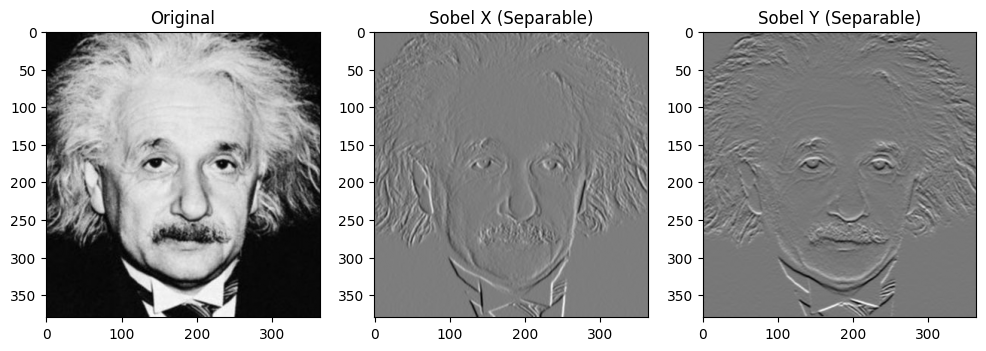

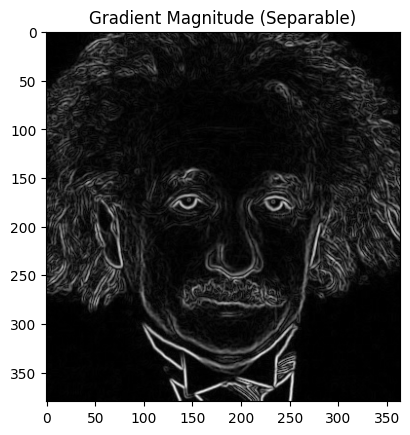

In [ ]:
kx = np.array([1, 0, -1], dtype=np.float32).reshape(1, 3)   # horizontal
ky = np.array([1, 2, 1], dtype=np.float32).reshape(3, 1)    # vertical

intermediate = cv.filter2D(image_6, cv.CV_32F, kx)

grad_x_sep = cv.filter2D(intermediate, cv.CV_32F, ky)

kx_y = np.array([1, 2, 1], dtype=np.float32).reshape(1, 3)
ky_y = np.array([1, 0, -1], dtype=np.float32).reshape(3, 1)

intermediate_y = cv.filter2D(image_6, cv.CV_32F, kx_y)
grad_y_sep = cv.filter2D(intermediate_y, cv.CV_32F, ky_y)

grad_mag = np.sqrt(grad_x_sep**2 + grad_y_sep**2)
grad_mag = np.uint8(255 * grad_mag / np.max(grad_mag))

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1); plt.imshow(image_6, cmap='gray'); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(grad_x_sep, cmap='gray'); plt.title("Sobel X (Separable)")
plt.subplot(1, 3, 3); plt.imshow(grad_y_sep, cmap='gray'); plt.title("Sobel Y (Separable)")
plt.show()

plt.imshow(grad_mag, cmap='gray'); plt.title("Gradient Magnitude (Separable)")
plt.show()

# Question 07

In [18]:
def zoom_image(img, factor, method="nearest"):
    h, w = img.shape[:2]
    new_h, new_w = int(h * factor), int(w * factor)
    result = np.zeros((new_h, new_w), dtype=img.dtype)

    if method == "nearest":
        for i in range(new_h):
            for j in range(new_w):
                src_x = int(i / factor)
                src_y = int(j / factor)
                result[i, j] = img[src_x, src_y]

    elif method == "bilinear":
        for i in range(new_h):
            for j in range(new_w):
                x = i / factor
                y = j / factor

                x0, y0 = int(np.floor(x)), int(np.floor(y))
                x1, y1 = min(x0+1, h-1), min(y0+1, w-1)

                dx, dy = x - x0, y - y0

                val = (1-dx)*(1-dy)*img[x0, y0] + dx*(1-dy)*img[x1, y0] + \
                      (1-dx)*dy*img[x0, y1] + dx*dy*img[x1, y1]

                result[i, j] = int(val)

    return result

In [19]:
def normalized_ssd(img1, img2):
    diff = (img1.astype(np.float32) - img2.astype(np.float32)) ** 2
    ssd = np.sum(diff)
    norm = np.sum(img1.astype(np.float32) ** 2)
    return ssd / norm

Normalized SSD (Nearest): 0.011756
Normalized SSD (Bilinear): 0.017260


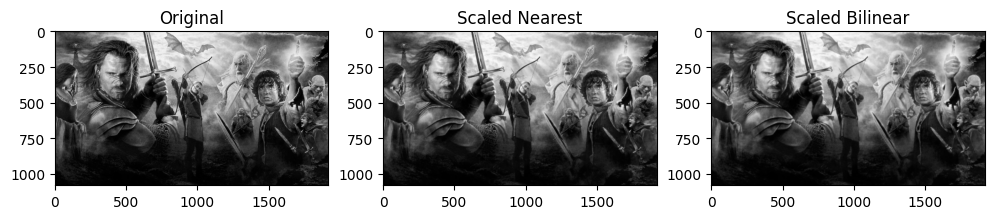

In [20]:
import matplotlib.pyplot as plt

orig = cv.imread("a1images/a1q8images/im01.png", cv.IMREAD_GRAYSCALE)
small = cv.imread("a1images/a1q8images/im01small.png", cv.IMREAD_GRAYSCALE)

scaled_nn = zoom_image(small, 4, method="nearest")
scaled_bl = zoom_image(small, 4, method="bilinear")

orig_resized = cv.resize(orig, (scaled_nn.shape[1], scaled_nn.shape[0]))

ssd_nn = normalized_ssd(orig_resized, scaled_nn)
ssd_bl = normalized_ssd(orig_resized, scaled_bl)

print(f"Normalized SSD (Nearest): {ssd_nn:.6f}")
print(f"Normalized SSD (Bilinear): {ssd_bl:.6f}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1); plt.imshow(orig_resized, cmap='gray'); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(scaled_nn, cmap='gray'); plt.title("Scaled Nearest")
plt.subplot(1, 3, 3); plt.imshow(scaled_bl, cmap='gray'); plt.title("Scaled Bilinear")
plt.show()

# Question 08

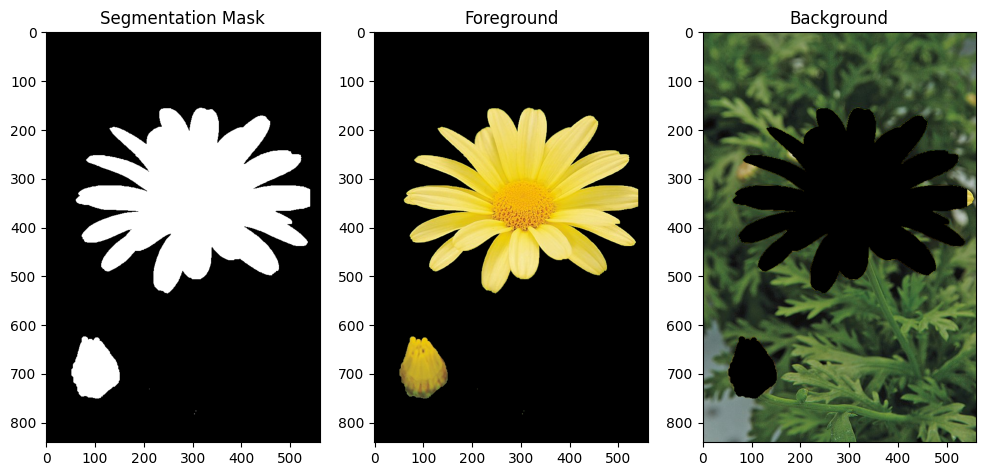

In [ ]:
image_7 = cv.imread("a1images/daisy.jpg")
mask = np.zeros(image_7.shape[:2], np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

rect = (20, 20, image_7.shape[1]-40, image_7.shape[0]-40)

cv.grabCut(image_7, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

foreground = image_7 * mask2[:, :, np.newaxis]
background = image_7 * (1 - mask2[:, :, np.newaxis])

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1); plt.imshow(mask2*255, cmap='gray'); plt.title("Segmentation Mask")
plt.subplot(1, 3, 2); plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB)); plt.title("Foreground")
plt.subplot(1, 3, 3); plt.imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB)); plt.title("Background")
plt.show()

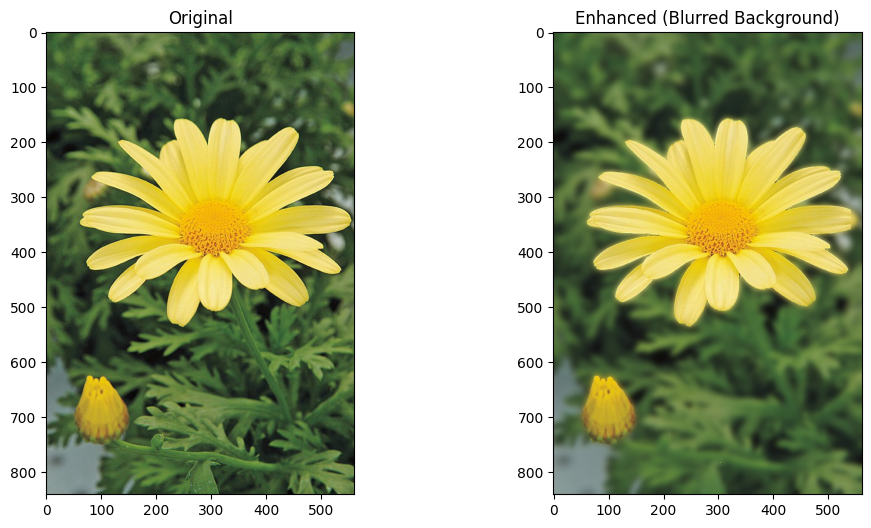

In [24]:
blurred_bg = cv.GaussianBlur(image_7, (31, 31), 0)

enhanced = blurred_bg.copy()
enhanced[mask2 == 1] = image_7[mask2 == 1]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(image_7, cv.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB)); plt.title("Enhanced (Blurred Background)")
plt.show()

# Question 09

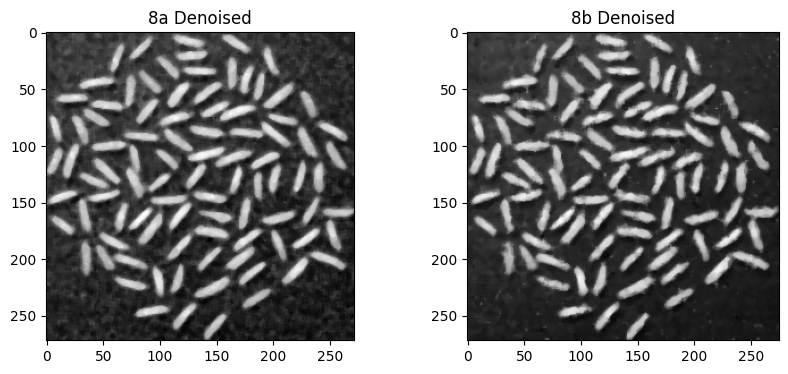

In [ ]:
image_8a = cv.imread('a1images/rice_8a.png', cv.IMREAD_GRAYSCALE)
image_8b = cv.imread('a1images/rice_8b.png', cv.IMREAD_GRAYSCALE)

image_8a_denoised = cv.medianBlur(image_8a, 5)
image_8b_denoised = cv.medianBlur(image_8b, 5)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(image_8a_denoised, cmap='gray'); plt.title('8a Denoised')
plt.subplot(1,2,2); plt.imshow(image_8b_denoised, cmap='gray'); plt.title('8b Denoised')
plt.show()

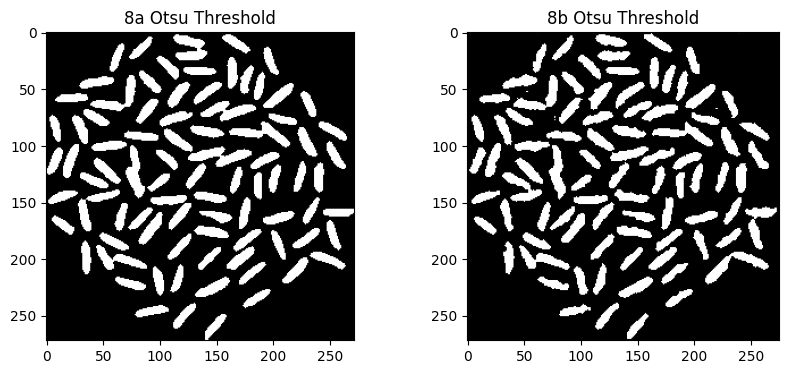

In [27]:
_, threshold_8a = cv.threshold(image_8a_denoised, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
_, threshold_8b = cv.threshold(image_8b_denoised, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(threshold_8a, cmap='gray'); plt.title('8a Otsu Threshold')
plt.subplot(1,2,2); plt.imshow(threshold_8b, cmap='gray'); plt.title('8b Otsu Threshold')
plt.show()

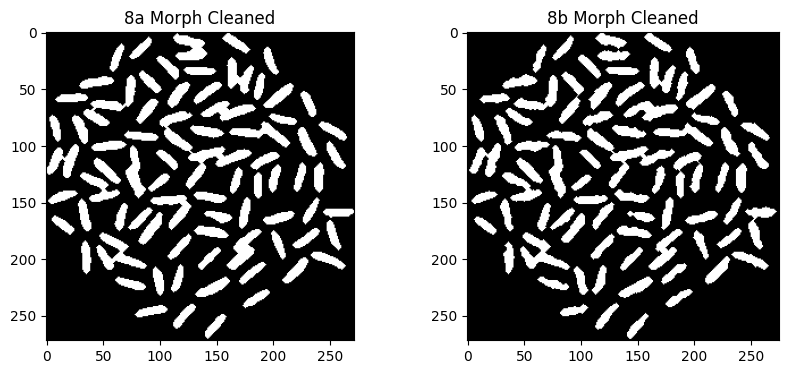

In [ ]:
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3))

clean_8a = cv.morphologyEx(thresh_8a, cv.MORPH_OPEN, kernel, iterations=2)
clean_8b = cv.morphologyEx(thresh_8b, cv.MORPH_OPEN, kernel, iterations=2)

clean_8a = cv.morphologyEx(clean_8a, cv.MORPH_CLOSE, kernel, iterations=2)
clean_8b = cv.morphologyEx(clean_8b, cv.MORPH_CLOSE, kernel, iterations=2)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(clean_8a, cmap='gray'); plt.title('8a Morph Cleaned')
plt.subplot(1,2,2); plt.imshow(clean_8b, cmap='gray'); plt.title('8b Morph Cleaned')
plt.show()